In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,accuracy_score
from joblib import dump, load

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import mode
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier

from xai_aux import CFCalculations, simulate_noise_effect, add_feature_noise, flip_labels

In [2]:
warnings.filterwarnings("ignore", message="X has feature names, but RandomForestClassifier was fitted without feature names")
warnings.filterwarnings("ignore", message="X has feature names, but LogisticRegression was fitted without feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but OneHotEncoder was fitted with feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but StandardScaler was fitted with feature names")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*At this time, the v2.11\\+ optimizer.*")

In [3]:
# inputs
mock_data = 3
cat_mock_data = True
non_iid = False

In [4]:
def plot_decision_boundary(clf, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.Paired)
    ax.set_title(title)

In [5]:
if not cat_mock_data:
    if mock_data==1:
        n_samples = 3000
        n_features = 2
        n_informative = 2
        n_redundant = 0
        class_sep = 1
        flip_y=0.01
        cat_feat = []
        num_feat = [i for i in range(n_features)]
        polytopes = []
    elif mock_data==2:
        n_samples = 3000
        n_features = 12
        n_informative = 10
        n_redundant = 2
        class_sep = 3 # 1
        flip_y=0.01
        cat_feat = []
        num_feat = [i for i in range(n_features)]
        polytopes = []
    else:
        pass

    X, y = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=n_informative,
        weights = [0.6], n_redundant=n_redundant, class_sep=class_sep, flip_y=0.005, random_state=42
    )

    # Store results
    results = []
    datasets = [[X,y]]
    decision_boundary_models = []
    decision_boundary_datasets = []

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    steps = 11 # first step is the default
    feature_noise_levels = np.linspace(0, 1., steps)  # Adjust range to control feature noise impact
    label_flip_fractions = np.linspace(0, 0.2, steps)  # Adjust range to control label noise impact

    # Loop through combinations of feature noise and label noise
    for feature_noise_level, label_flip_fraction in zip(feature_noise_levels, label_flip_fractions):

        # Add feature noise
        X_noisy = add_feature_noise(X, feature_noise_level)
        # Add label noise
        y_noisy = flip_labels(y, label_flip_fraction)

        X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
            X_noisy, y_noisy, test_size=0.3, random_state=42
        )

        datasets.append([X_noisy,y_noisy])
        decision_boundary_datasets.append([X_test_noisy,y_test_noisy])

        # Train classifier
        #clf = DecisionTreeClassifier(random_state=42)
        #clf = LogisticRegression(random_state=42)
        clf = MLPClassifier()
        clf.fit(X_train_noisy, y_train_noisy)
        
        decision_boundary_models.append(clf)

        # Predict and calculate accuracy
        y_pred = clf.predict(X_test_noisy)
        accuracy = accuracy_score(y_test_noisy, y_pred)

        # Store results
        results.append({
            'feature_noise_level': feature_noise_level,
            'label_flip_fraction': label_flip_fraction,
            'accuracy': accuracy
        })

    # Convert results to DataFrame for further analysis
    results_df = pd.DataFrame(results)

    # Display results
    print(results_df)

    # Optional: Visualize accuracies
    plt.figure(figsize=(8, 6))
    plt.plot(np.arange(0, steps), results_df['accuracy'], marker='o', label='Accuracy')
    plt.xlabel('Noise')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Noise Levels')
    plt.grid()
    plt.xticks(ticks=np.arange(0, steps), labels=[f"Level {i}" for i in range(0, steps)])
    plt.show()

    # Plot feature noise vs. label noise impact
    plt.figure(figsize=(8, 6))
    plt.scatter(results_df['feature_noise_level'], results_df['accuracy'], c='blue', label='Feature Noise')
    plt.scatter(results_df['label_flip_fraction'], results_df['accuracy'], c='orange', label='Label Noise')
    plt.xlabel('Noise Level')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Impact of Noise Levels on Accuracy')
    plt.grid()
    plt.show()

    if n_features==2:
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        plot_decision_boundary(decision_boundary_models[0], decision_boundary_datasets[0][0], decision_boundary_datasets[0][1], f"Original (Accuracy: {results_df['accuracy'][0]:.2f})", axes[0])
        plot_decision_boundary(decision_boundary_models[4], decision_boundary_datasets[4][0], decision_boundary_datasets[4][1], f"Halfway Noise (Accuracy: {results_df['accuracy'][4]:.2f})", axes[1])
        plot_decision_boundary(decision_boundary_models[-1], decision_boundary_datasets[-1][0], decision_boundary_datasets[-1][1], f"Full Noise (Accuracy: {results_df['accuracy'].values[-1]:.2f})", axes[2])
        plt.tight_layout()
        plt.show()

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warning

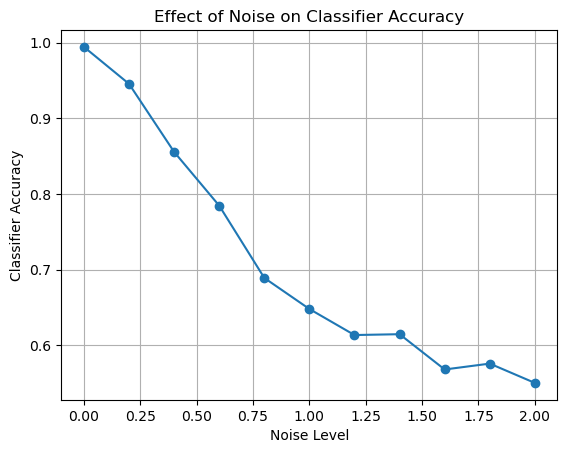

In [6]:
if mock_data==3 and cat_mock_data:
    n_samples = 3000
    n_features = 10
    n_informative = 10
    n_redundant = 0
    class_sep = 3 # 1
    flip_y=0.01
    cat_feat = [0, 1, 2, 3, 4]
    num_feat = [5, 6, 7, 8, 9]
    polytopes = [[1,2,3],[4,5,6]] # each columns expands to three. 1 to 1,2,3 and 2 to 4,5,6
    X, y = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=10,
        weights = [0.6], n_redundant=0, class_sep=class_sep, flip_y=0.005, random_state=43
    )

    # first column becomes 4 categorical variables
    est = KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='uniform')
    est.fit(X[:,0].reshape(-1,1))  
    X1 = est.transform(X[:,0].reshape(-1,1)) 
    categorical_values = np.argmax(X1, axis=1)
    categories = ['AA', 'AB', 'AC', 'AD']
    x1 = np.array([categories[i] for i in categorical_values]).reshape(-1,1)

    # second column becomes 4 categorical variables
    est.fit(X[:,1].reshape(-1,1))
    X2 = est.transform(X[:,1].reshape(-1,1))
    categorical_values = np.argmax(X2, axis=1)
    categories = ['BA', 'BB', 'BC', 'BD']
    x2 = np.array([categories[i] for i in categorical_values]).reshape(-1,1)

    # columns 3 to 6 become binary variables
    transformer = Binarizer().fit(X[:,2:5])  # fit does nothing.
    X3 = transformer.fit_transform(X[:,2:5])

    df = pd.DataFrame(
        np.concatenate((x1, 
        x2, 
        np.where(X3[:,0]==0, "Low", "High").reshape(-1,1), 
        np.where(X3[:,1]==0, "No", "Yes").reshape(-1,1), 
        np.where(X3[:,2]==0, "Active", "Inactive").reshape(-1,1), 
        X[:,5:]),axis=1),
        columns = [str(i) for i in range(n_features)]
        )

    results, datasets = simulate_noise_effect(df, [str(i) for i in num_feat], [str(i) for i in cat_feat], y, max_noise=2., step=0.2)

    noise_levels, accuracies = zip(*results)
    plt.plot(noise_levels, accuracies, marker='o')
    plt.xlabel('Noise Level')
    plt.ylabel('Classifier Accuracy')
    plt.title('Effect of Noise on Classifier Accuracy')
    plt.grid()
    plt.show()

In [7]:
if mock_data==4 and cat_mock_data:
    n_samples = 5000
    n_features = 40
    n_informative = 40
    n_redundant = 0
    class_sep = 2 # 1
    flip_y=0.05
    num_start = 20
    n_polytopes = 10
    cat_feat = [i for i in range(num_start)]
    num_feat = [i for i in range(num_start,n_features)]

    X, y = make_classification(
        n_samples=n_samples, 
        n_features=n_features, 
        n_informative=n_informative,
        n_redundant=n_redundant,
        class_sep=class_sep,
        weights = [0.6], 
        flip_y=flip_y, 
        random_state=43
    )

    # first 10 columns becomes 10 categorical variables with up to 7 categories. 
    x1 = []
    polytopes = []
    for i in range(n_polytopes):
        n_bins = np.random.uniform(low=3, high=10, size=(1,)).astype(int)[0]
        est = KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='uniform')
        est.fit(X[:,i].reshape(-1,1))  
        X1 = est.transform(X[:,i].reshape(-1,1)) 
        categorical_values = np.argmax(X1, axis=1)
        categories = random.sample(string.ascii_letters, n_bins)
        x1.append(np.array([categories[i] for i in categorical_values]).reshape(-1,1))
        polytopes.append([j+1 for j in range(n_bins-1)])

    prev_last = 0
    for i in range(len(polytopes)):
        polytopes[i] = [x + prev_last for x in polytopes[i]]
        prev_last = polytopes[i][-1]  # Update the last element of the current list

    # columns 3 to 6 become binary variables
    transformer = Binarizer().fit(X[:,n_polytopes:num_start])  # fit does nothing.
    x2 = transformer.fit_transform(X[:,n_polytopes:num_start])
    x2a = np.where(x2[:,0]==0, "No", "Yes").reshape(-1,1)
    for i in range(1, x2.shape[1]):
        x2a = np.hstack([x2a, np.where(x2[:,i]==0, "No", "Yes").reshape(-1,1)])

    df = pd.DataFrame(
        np.concatenate((np.column_stack(x1), x2a, X[:,num_start:]),axis=1), 
        columns = [str(i) for i in range(n_features)]
        )

    results, datasets = simulate_noise_effect(df, [str(i) for i in num_feat], [str(i) for i in cat_feat], y, max_noise=2., step=0.2)

    noise_levels, accuracies = zip(*results)
    plt.plot(noise_levels, accuracies, marker='o')
    plt.xlabel('Noise Level')
    plt.ylabel('Classifier Accuracy')
    plt.title('Effect of Noise on Classifier Accuracy')
    plt.grid()
    plt.show()

In [8]:
model_results_dict = {}
cf_results_dict = {}
cm_results_dict = {}
cfs_good_indices = {}
for c1, dataset_in in enumerate(datasets):
    print("Working on dataset ", str(c1))
    X = dataset_in[0]
    y = dataset_in[1]
    df = pd.DataFrame(X, columns=[str(i) for i in range(n_features)])
    df_train, df_test, y_train, y_test, indices_train, indices_test = train_test_split(df, y, np.arange(len(X)), test_size=0.33, random_state=42)
    if non_iid:
        outlier_indices = np.random.choice(len(df_test), n_samples//10, replace=False)
        df_test.iloc[outlier_indices, 5:] *= 5
    cf_calc = CFCalculations(df_train, y_train, df_test, y_test, cat_feat, num_feat, polytopes) # no constant assummed
    print(pd.DataFrame([(model, metric, value) for (model, metric), value in cf_calc.model_stats.items()], columns=['Model', 'Metric', 'Value']))
    model_results_dict[f"noise_{c1:.0f}"] = cf_calc.model_stats
    cm_results_dict[f"noise_{c1:.0f}"] = cf_calc.cms
    cfs = cf_calc.get_cfs()
    cfs_good_indices[f"noise_{c1:.0f}"] = cf_calc.check_cfs()
    cf_results_dict[f"noise_{c1:.0f}"] = cfs

    dump(cf_calc, "mock_data"+str(mock_data)+"_"+str(c1)+".pkl")
    dump(cf_results_dict, "mock_data"+str(mock_data)+"_cf_results_dict.pkl")
    dump(model_results_dict, "mock_data"+str(mock_data)+"_model_results.pkl")
    dump(cfs_good_indices, "mock_data"+str(mock_data)+"_cfs_good_indices.pkl")
    print("==================================================================================================")

Working on dataset  0


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 52 seconds.


31/31 [==============================] - 0s 425us/step - loss: 0.0694 - accuracy: 0.9869 - precision: 0.9754
TF Test Accuracy: 98.69%
31/31 [==============================] - 0s 379us/step
  Model     Metric     Value
0    lr   accuracy  0.986869
1    lr  precision  0.986876
2   blr   accuracy  0.986869
3   blr  precision  0.986876
4    rf   accuracy  0.990909
5    rf  precision  0.990939
6    tf   accuracy  0.986869
7    tf  precision  0.987007
Working on lr skl
Working on lr blr_marg
